# Customer Retention Intelligence
## 00 — Data Acquisition & Exploratory Data Analysis

### Objective

The goal of this notebook is to acquire the customer churn dataset and understand the data before building any machine learning models.

### Workflow

1. Download and store the raw dataset.
2. Inspect the structure of the dataset.
3. Understand what each row and feature represents.
4. Check data types, missing values, duplicates, and potential data quality issues.
5. Examine the churn target and class distribution.
6. Explore relationships between customer characteristics and churn.

### Questions to Answer

- What does one row represent?
- What is the target variable?
- Which features are numerical and which are categorical?
- Are there missing or malformed values?
- Are there duplicate customers?
- Is the target class balanced?
- Which customer characteristics appear related to churn?
- Are there features that should not be used for prediction?

## 1. Data Acquisition

We will use the IBM Telco Customer Churn dataset.  
The raw dataset will be stored locally under `data/raw/` so that the analysis is reproducible and the original data remains unchanged.

In [3]:
from pathlib import Path
from urllib.request import urlretrieve

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

RAW_DATA_DIR = Path("../data/raw")
DATA_PATH = RAW_DATA_DIR / "Telco-Customer-Churn.csv"

In [4]:
if not DATA_PATH.exists():
    urlretrieve(DATA_URL, DATA_PATH)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")

Dataset already exists.


## 2. Initial Data Inspection

Now that the raw dataset has been downloaded, we will load it into a Pandas DataFrame and inspect its structure.

At this stage, we are not modifying the data. The goal is simply to understand what we are working with.

We will inspect the dataset dimensions, columns, data types, and target distribution before cleaning or modeling.

In [5]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [11]:
df["TotalCharges"].head(15)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
Name: TotalCharges, dtype: str

In [12]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [13]:
df[df["TotalCharges"].str.strip().eq("")]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Observation

`TotalCharges` contains 11 blank values. All of these customers have `tenure = 0`, suggesting they are new customers with no accumulated billing history yet.

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
df["TotalCharges"].dtype
df["TotalCharges"].isna().sum()

np.int64(0)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["customerID"].nunique()

7043

## 4. Exploratory Data Analysis

Now that the main data quality issues have been identified, we will explore customer characteristics and look for patterns associated with churn.

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

## 4. Churn Analysis

The goal of this section is to identify customer characteristics, services, and account features that are associated with higher or lower churn rates.

In [22]:
# Create binary churn flag for easier rate calculations
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})

# Create tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

# Grouped churn analyses
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

tenure_churn = (
    df.groupby("TenureGroup", observed=True)["ChurnFlag"]
      .agg(["mean", "count"])
)

internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

techsupport_churn = (
    df.groupby("TechSupport")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

security_churn = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

paperless_churn = (
    df.groupby("PaperlessBilling")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

senior_churn = (
    df.groupby("SeniorCitizen")["ChurnFlag"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

charges_churn = (
    df.groupby("Churn")[["MonthlyCharges", "TotalCharges", "tenure"]]
      .agg(["mean", "median"])
)

# Convert churn-rate means to percentages
for table in [
    contract_churn,
    tenure_churn,
    internet_churn,
    payment_churn,
    techsupport_churn,
    security_churn,
    paperless_churn,
    senior_churn
]:
    table["churn_rate_pct"] = table["mean"] * 100

# Print results
print("=== CONTRACT ===")
display(contract_churn)

print("=== TENURE GROUP ===")
display(tenure_churn)

print("=== CHARGES & TENURE BY CHURN ===")
display(charges_churn)

print("=== INTERNET SERVICE ===")
display(internet_churn)

print("=== PAYMENT METHOD ===")
display(payment_churn)

print("=== TECH SUPPORT ===")
display(techsupport_churn)

print("=== ONLINE SECURITY ===")
display(security_churn)

print("=== PAPERLESS BILLING ===")
display(paperless_churn)

print("=== SENIOR CITIZEN ===")
display(senior_churn)

=== CONTRACT ===


,mean,count,churn_rate_pct
Contract,,,
Month-to-month,0.427097,3875,42.709677
One year,0.112695,1473,11.269518
Two year,0.028319,1695,2.831858


=== TENURE GROUP ===


,mean,count,churn_rate_pct
TenureGroup,,,
0-6,0.529372,1481,52.937205
7-12,0.358865,705,35.886525
13-24,0.287109,1024,28.710938
25-48,0.203890,1594,20.388959
49-72,0.095132,2239,9.513176


=== CHARGES & TENURE BY CHURN ===


...

,mean,count,churn_rate_pct
OnlineSecurity,,,
No,0.417667,3498,41.766724
Yes,0.146112,2019,14.611194
No internet service,0.074050,1526,7.404980


=== PAPERLESS BILLING ===


,mean,count,churn_rate_pct
PaperlessBilling,,,
Yes,0.335651,4171,33.565092
No,0.163301,2872,16.330084


=== SENIOR CITIZEN ===


,mean,count,churn_rate_pct
SeniorCitizen,,,
1,0.416813,1142,41.681261
0,0.236062,5901,23.606168


### Key Findings

The exploratory analysis reveals several strong patterns associated with customer churn:

- **Contract type shows one of the strongest relationships with churn.** Month-to-month customers have a churn rate of approximately **42.7%**, compared with **11.3%** for one-year contracts and only **2.8%** for two-year contracts.

- **Churn is strongly concentrated among newer customers.** Customers with 0–6 months of tenure churn at approximately **52.9%**, while customers with 49–72 months of tenure churn at only **9.5%**.

- Customers who churn have substantially shorter tenure, with an average of approximately **18 months**, compared with approximately **37.6 months** for customers who remain.

- **Higher monthly charges are associated with churn.** Churned customers pay an average monthly charge of approximately **$74.44**, compared with **$61.27** for non-churned customers.

- Although churned customers have lower average `TotalCharges`, this is likely influenced by their much shorter tenure rather than lower spending behavior.

- **Fiber optic customers show a substantially higher churn rate** at approximately **41.9%**, compared with **19.0%** for DSL customers.

- **Electronic check users have the highest churn rate among payment methods**, at approximately **45.3%**. Automatic bank transfer and credit card customers have considerably lower churn rates.

- Customers without **TechSupport** or **OnlineSecurity** show churn rates above **41%**, while customers with these services have churn rates around **15%**.

- Customers using **paperless billing** have a churn rate of approximately **33.6%**, roughly twice the rate of customers who do not use paperless billing.

- **Senior citizens show higher churn**, approximately **41.7%**, compared with **23.6%** among non-senior customers.

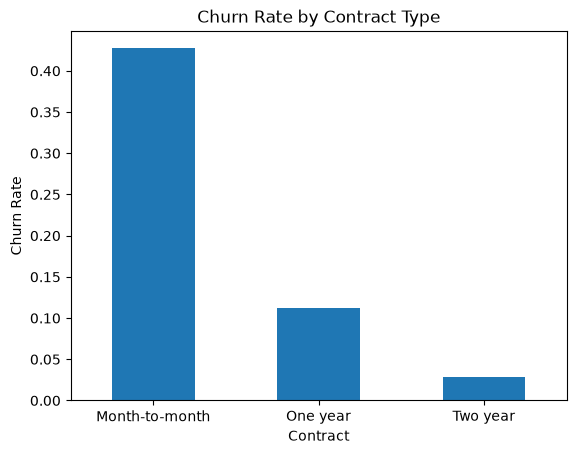

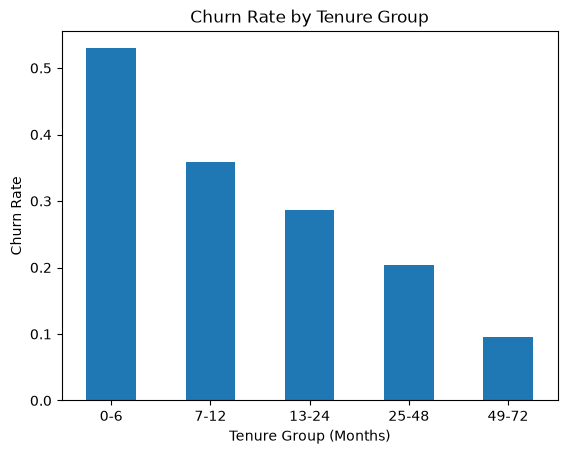

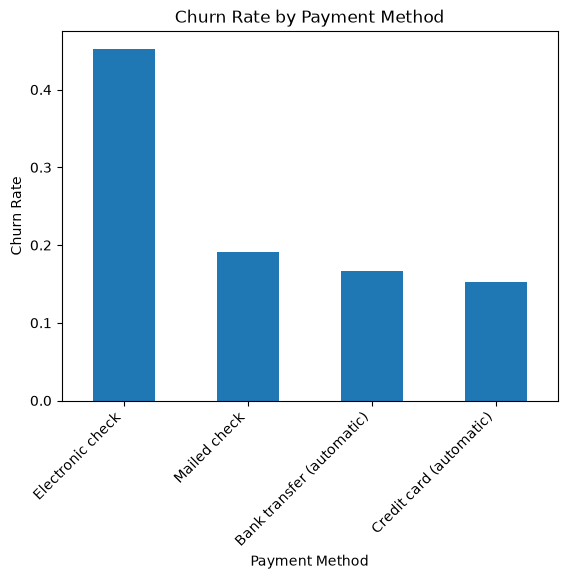

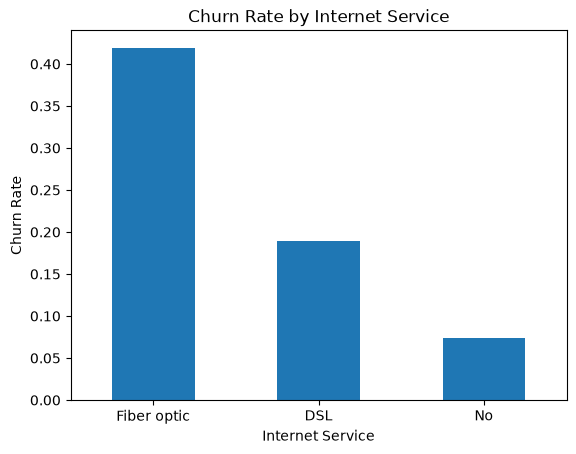

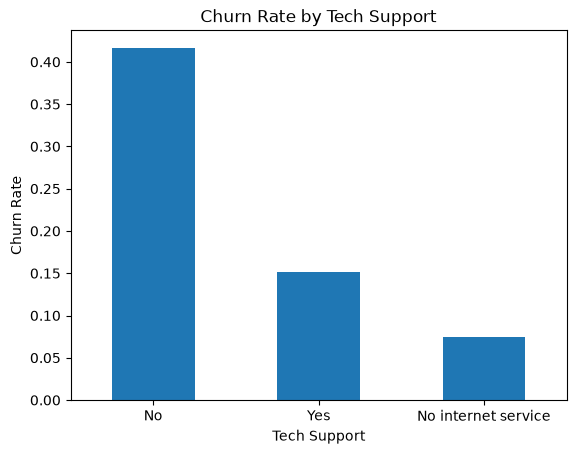

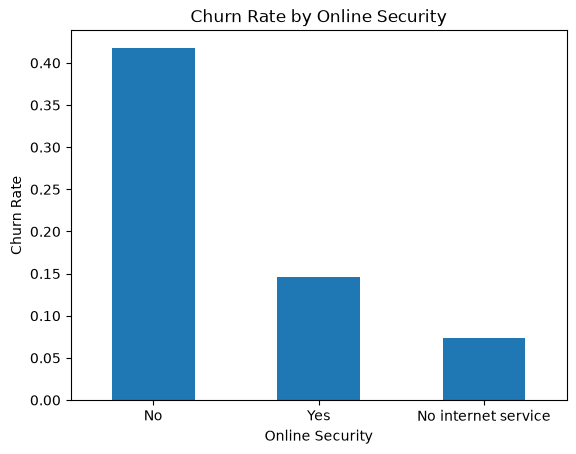

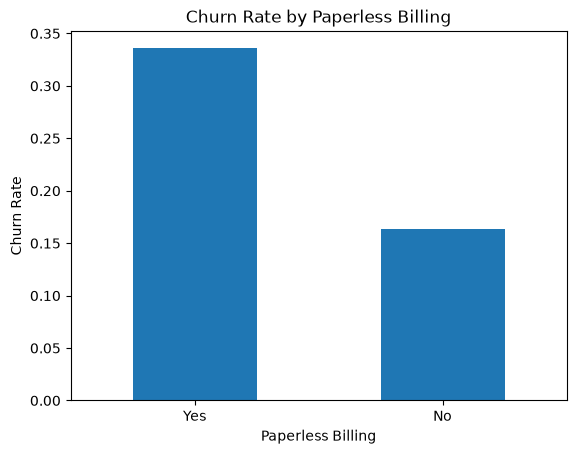

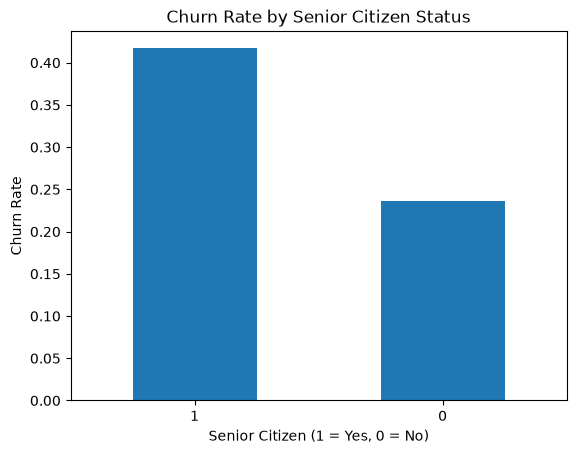

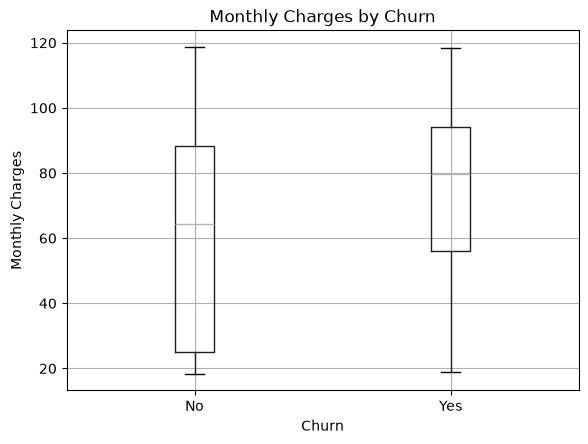

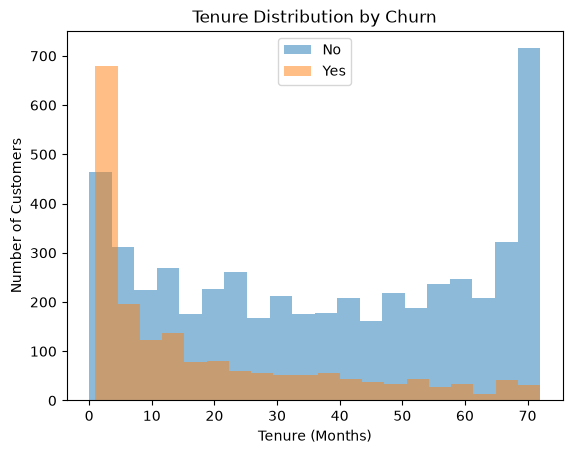

In [24]:
import matplotlib.pyplot as plt

# Contract
contract_rates = (
    df.groupby("Contract")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

contract_rates.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Tenure Group
tenure_rates = (
    df.groupby("TenureGroup", observed=True)["ChurnFlag"]
      .mean()
)

tenure_rates.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Payment Method
payment_rates = (
    df.groupby("PaymentMethod")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

payment_rates.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.show()


# Internet Service
internet_rates = (
    df.groupby("InternetService")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

internet_rates.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Tech Support
techsupport_rates = (
    df.groupby("TechSupport")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

techsupport_rates.plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Online Security
security_rates = (
    df.groupby("OnlineSecurity")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

security_rates.plot(kind="bar")
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Paperless Billing
paperless_rates = (
    df.groupby("PaperlessBilling")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

paperless_rates.plot(kind="bar")
plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Senior Citizen
senior_rates = (
    df.groupby("SeniorCitizen")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

senior_rates.plot(kind="bar")
plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (1 = Yes, 0 = No)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()


# Monthly Charges
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


# Tenure Distribution
df[df["Churn"] == "No"]["tenure"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="No"
)

df[df["Churn"] == "Yes"]["tenure"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="Yes"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

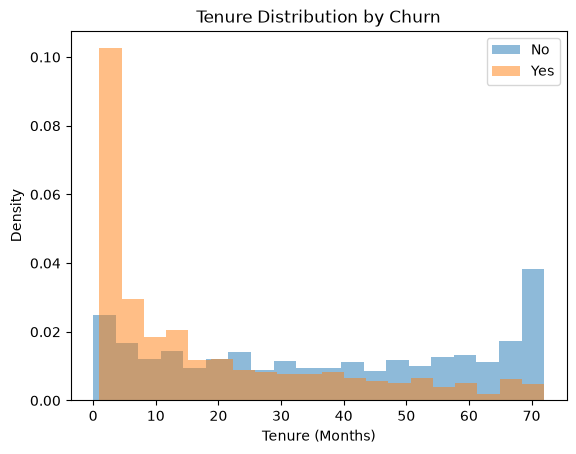

In [25]:
df[df["Churn"] == "No"]["tenure"].plot(
    kind="hist",
    bins=20,
    density=True,
    alpha=0.5,
    label="No"
)

df[df["Churn"] == "Yes"]["tenure"].plot(
    kind="hist",
    bins=20,
    density=True,
    alpha=0.5,
    label="Yes"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Conclusion

The EDA suggests that churn is most strongly associated with contract type, customer tenure, payment method, internet service, and access to support-related services.

Newer customers and month-to-month subscribers show particularly high churn rates, while long-term customers and customers on one- or two-year contracts are substantially more stable.

Several features appear related to one another, so these relationships should not be interpreted as causal effects. The next step is to build a multivariate classification model and evaluate whether these patterns remain useful when the features are considered together.

In [27]:
model_df = df.drop(columns=["ChurnFlag", "TenureGroup"])

PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_PATH = PROCESSED_DATA_DIR / "telco_churn_clean.csv"

model_df.to_csv(PROCESSED_DATA_PATH, index=False)